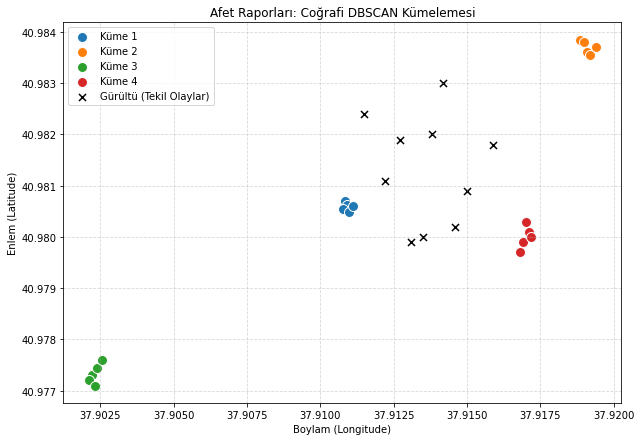

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# 1. JSON Verisini Okuma
# 'test_reports.json' dosyasının kod ile aynı dizinde olduğunu varsayıyoruz.
with open('test_reports.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Koordinatları çıkarma: JSON içinde [boylam, enlem] olarak tutuluyor.
coords = []
event_captures = []

for report in data['raw_reports']:
    lon, lat = report['gps_location']['coordinates']
    coords.append([lon, lat])
    event_captures.append(report['event_capture'])

X = np.array(coords)

# 2. DBSCAN Fonksiyonları (Senin algoritman)
def euclidean(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def region_query(X, point_idx, eps):
    neighbors = []
    for idx, point in enumerate(X):
        if euclidean(X[point_idx], point) < eps:
            neighbors.append(idx)
    return neighbors

def expand_cluster(X, labels, point_idx, cluster_id, eps, min_pts):
    neighbors = region_query(X, point_idx, eps)
    if len(neighbors) < min_pts:
        labels[point_idx] = -1  # Gürültü
        return False
    else:
        labels[point_idx] = cluster_id
        queue = deque(neighbors)
        while queue:
            current_point = queue.popleft()
            if labels[current_point] == -1:
                labels[current_point] = cluster_id
            elif labels[current_point] == 0:
                labels[current_point] = cluster_id
                new_neighbors = region_query(X, current_point, eps)
                if len(new_neighbors) >= min_pts:
                    queue.extend(new_neighbors)
        return True

def dbscan(X, eps, min_pts):
    cluster_id = 0
    n_points = len(X)
    labels = [0] * n_points  

    for point_idx in range(n_points):
        if labels[point_idx] == 0:
            if expand_cluster(X, labels, point_idx, cluster_id + 1, eps, min_pts):
                cluster_id += 1
    return labels

# 3. Parametreleri Ayarlama ve Çalıştırma
# GPS derecesi üzerinden ölçüm yaptığımız için eps değerini düşük tutuyoruz
# 0.002 derece yaklaşık 150-200 metre çapında bir alanı kapsar.
eps = 0.0005 
min_samples = 3

labels = dbscan(X, eps, min_samples)

# 4. Görselleştirme
plt.figure(figsize=(10, 7))
unique_labels = set(labels)

# Daha estetik bir renk paleti atayalım
colors = plt.cm.get_cmap("tab10", len(unique_labels))

for i, label in enumerate(unique_labels):
    mask = np.array(labels) == label
    if label == -1:
        # Gürültü noktaları
        plt.scatter(X[mask, 0], X[mask, 1], c='k', label='Gürültü (Tekil Olaylar)', marker='x', s=50)
    else:
        # Kümelenmiş noktalar
        plt.scatter(X[mask, 0], X[mask, 1], label=f'Küme {label}', s=100, edgecolors='white')

plt.legend()
plt.title('Afet Raporları: Coğrafi DBSCAN Kümelemesi')
plt.xlabel('Boylam (Longitude)')
plt.ylabel('Enlem (Latitude)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Merge İşlemi Tamamlandı!
Toplam nihai küme sayısı: 15

Küme Dağılım Detayları:
    final_cluster macro_category            raw_category  sayi
0               0          cevre                 heyelan     1
1               0          cevre               landslide     1
2               1        altyapi  infrastructure failure     1
3               1        altyapi           road collapse     1
4               1        altyapi         road_disruption     1
5               2          cevre                   flood     5
6               3          cevre                   flood     5
7               4        altyapi         elektrik kazası     2
8               4        altyapi      elektrik kesintisi     2
9               5          cevre                    fire     1
10              6          cevre                   flood     1
11              7          cevre                   flood     1
12              8          cevre                   flood     1
13              9          cevre       

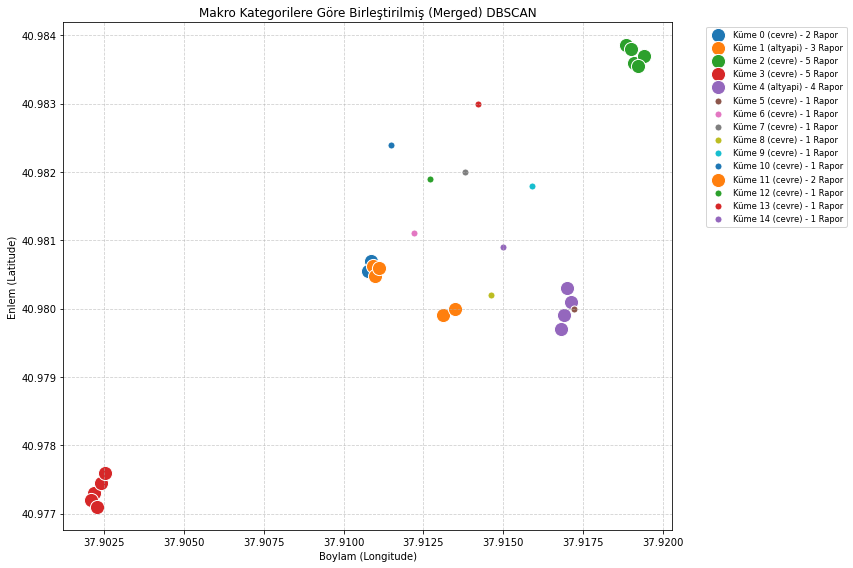

In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. JSON Verisini Okuma
with open('oasis_db_output.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. Makro Kategori Sözlüğü (Veriyi Altyapı, Çevre vb. olarak genelleştiriyoruz)
macro_mapping = {
    'road collapse': 'altyapi',
    'road_disruption': 'altyapi',
    'infrastructure failure': 'altyapi',
    'elektrik kesintisi': 'altyapi',
    'elektrik kazası': 'altyapi',
    'flood': 'cevre',
    'heyelan': 'cevre',
    'landslide': 'cevre',
    'fire': 'cevre'
}

parsed_data = []
for r in data['processed_reports']:
    lon, lat = r['gps_location']['coordinates']
    raw_cat = r['disaster_type'].lower().strip()
    
    # Raw category sözlükte varsa makro kategoriyi al, yoksa 'diger' yap
    macro_cat = macro_mapping.get(raw_cat, 'diger')
    
    parsed_data.append({
        'id': r['id'], 
        'report_id': r['report_id'],
        'lat': lat, 
        'lon': lon, 
        'raw_category': raw_cat,
        'macro_category': macro_cat
    })

df = pd.DataFrame(parsed_data)

# 3. ADIM: Sadece Konum Bazlı DBSCAN (0.0005 epsilon)
spatial_dbscan = DBSCAN(eps=0.0005, min_samples=2)
df['spatial_cluster'] = spatial_dbscan.fit_predict(df[['lat', 'lon']])

# 4. ADIM: Konum ve Makro Kategoriyi Merge Etme (Tekil Olayları Koruyarak)
final_clusters = []
cluster_map = {}
cluster_id_counter = 0

for idx, row in df.iterrows():
    s_id = row['spatial_cluster']
    m_cat = row['macro_category']
    
    if s_id == -1:
        # Gürültü değil, tek başına bir olay (Cluster of 1)
        final_clusters.append(cluster_id_counter)
        cluster_id_counter += 1
    else:
        # Kesişim Anahtarı: (Mekansal Küme ID, Makro Kategori)
        # Artık "road collapse" ve "elektrik kesintisi" aynı mekandaysa ikisi de 'altyapi' 
        # olduğu için aynı cluster_map anahtarına düşecek ve birleşecek.
        merge_key = (s_id, m_cat)
        
        if merge_key not in cluster_map:
            cluster_map[merge_key] = cluster_id_counter
            cluster_id_counter += 1
            
        final_clusters.append(cluster_map[merge_key])

df['final_cluster'] = final_clusters

# Sonuç Özeti
print("Merge İşlemi Tamamlandı!")
print(f"Toplam nihai küme sayısı: {cluster_id_counter}")

# Hangi Makro Kategoride Hangi Alt Olaylar Birleşti Görelim:
print("\nKüme Dağılım Detayları:")
summary = df.groupby(['final_cluster', 'macro_category', 'raw_category']).size().reset_index(name='sayi')
print(summary)

# 5. Görselleştirme
plt.figure(figsize=(12, 8))
unique_clusters = df['final_cluster'].unique()
colors = plt.cm.get_cmap("tab10", len(unique_clusters))

for cluster_id in unique_clusters:
    subset = df[df['final_cluster'] == cluster_id]
    m_cat_name = subset['macro_category'].iloc[0]
    
    # Tekil olaylar küçük, grup kümeler büyük
    marker_size = 50 if len(subset) == 1 else 200
    
    plt.scatter(subset['lon'], subset['lat'], marker='o', s=marker_size, edgecolors='white', 
                label=f"Küme {cluster_id} ({m_cat_name}) - {len(subset)} Rapor")

plt.title('Makro Kategorilere Göre Birleştirilmiş (Merged) DBSCAN')
plt.xlabel('Boylam (Longitude)')
plt.ylabel('Enlem (Latitude)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

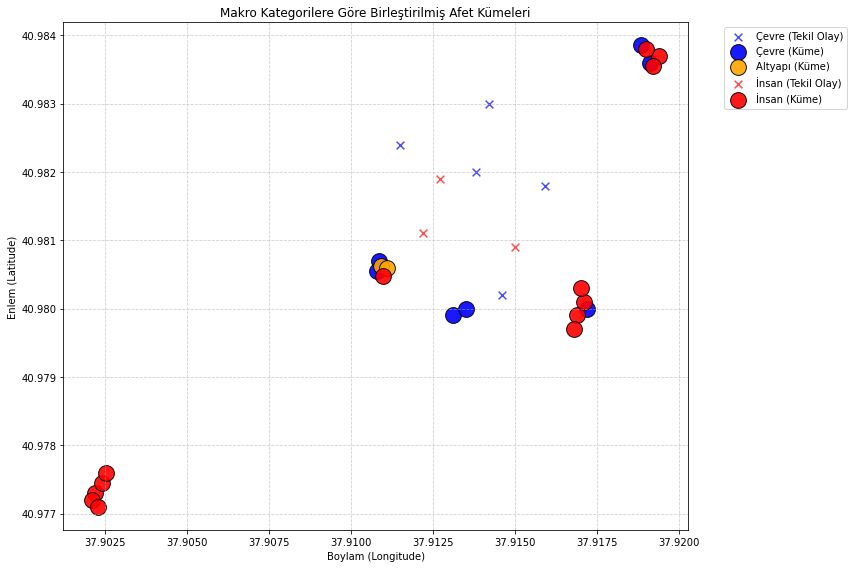

Kümeleme Tamamlandı!
Toplam nihai küme sayısı: 9
Toplam tekil olay sayısı: 8


In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. JSON Verisini Okuma
with open('oasis_db_output.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. Makro Kategori Belirleme (Sadece Altyapı ve Çevre için temel sözlük)
macro_mapping = {
    'road collapse': 'altyapi',
    'road_disruption': 'altyapi',
    'infrastructure failure': 'altyapi',
    'elektrik kesintisi': 'altyapi',
    'elektrik kazası': 'altyapi',
    'flood': 'cevre',
    'heyelan': 'cevre',
    'landslide': 'cevre',
    'fire': 'cevre'
}

parsed_data = []
for r in data['processed_reports']:
    lon, lat = r['gps_location']['coordinates']
    # Eğer orijinal afet tipine göre kümeleme yapmak isterseniz macro_category 
    # yerine raw_cat kullanabilirsiniz. Şimdilik makro kategoriyi baz alıyoruz.
    raw_cat = r['disaster_type'].lower().strip()
    
    # --- İNSAN KATEGORİSİ KONTROLÜ (ÖNCELİKLİ) ---
    indicators = r.get('indicators_json', {})
    user_status = r.get('user_status', '')
    
    is_human_risk = (
        indicators.get('people_trapped', False) or 
        indicators.get('people_injured', False) or 
        indicators.get('life_threat', False) or
        user_status == 'entrapment-life-threatening-risk'
    )
    
    if is_human_risk:
        macro_cat = 'insan'
    else:
        macro_cat = macro_mapping.get(raw_cat, 'diger')
        
    parsed_data.append({
        'id': r['id'], 
        'lat': lat, 
        'lon': lon, 
        'macro_category': macro_cat,
        'raw_category': raw_cat # İstenirse diye ham veriyi de tutalım
    })

df = pd.DataFrame(parsed_data)

# 3. ve 4. ADIM: Hem Makro Kategoriye Hem Konuma Göre Bağımsız DBSCAN
# Her kategori için DBSCAN'i ayrı ayrı çalıştırıyoruz.
df['final_cluster'] = -1
global_cluster_id = 0

# Burada macro_category yerine 'raw_category' yazarsanız doğrudan "flood", "fire" gibi
# alt afet tiplerine göre spesifik kümeleme yapar.
for cat_name, group_df in df.groupby('macro_category'):
    
    # Küme oluşturmak için en az min_samples (2) kadar veri olmalı
    if len(group_df) >= 2:
        # Sadece bu kategoriye ait olan veriler üzerinde konumsal tarama yapıyoruz
        dbscan = DBSCAN(eps=0.0005, min_samples=2)
        local_clusters = dbscan.fit_predict(group_df[['lat', 'lon']])
        
        # Local cluster ID'leri (0, 1, 2...) global (benzersiz) cluster ID'lere çevir
        unique_local_clusters = set(local_clusters) - {-1}
        
        # Yerel ID'den Global ID'ye haritalama sözlüğü
        cluster_mapping = {}
        for local_id in unique_local_clusters:
            cluster_mapping[local_id] = global_cluster_id
            global_cluster_id += 1
            
        # Orijinal DataFrame'e atama yap
        for idx, loc_id in zip(group_df.index, local_clusters):
            if loc_id != -1:
                df.at[idx, 'final_cluster'] = cluster_mapping[loc_id]


# 5. Görselleştirme
plt.figure(figsize=(12, 8))

cat_style = {
    'insan':   {'color': 'red',    'label': 'İnsan'},
    'altyapi': {'color': 'orange', 'label': 'Altyapı'},
    'cevre':   {'color': 'blue',   'label': 'Çevre'},
    'diger':   {'color': 'gray',   'label': 'Diğer'}
}

for cat in df['macro_category'].unique():
    cat_df = df[df['macro_category'] == cat]
    color = cat_style[cat]['color']
    label = cat_style[cat]['label']
    
    # Tekil Olayları çiz
    tekil_df = cat_df[cat_df['final_cluster'] == -1]
    if not tekil_df.empty:
        plt.scatter(tekil_df['lon'], tekil_df['lat'], 
                    color=color, marker='x', s=60, alpha=0.7, 
                    label=f"{label} (Tekil Olay)")
    
    # Kümeleri çiz
    kume_df = cat_df[cat_df['final_cluster'] != -1]
    if not kume_df.empty:
        plt.scatter(kume_df['lon'], kume_df['lat'], 
                    color=color, marker='o', s=250, edgecolors='black', alpha=0.9, 
                    label=f"{label} (Küme)")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Kategoriye Özgü Ayrıştırılmış Afet Kümeleri (DBSCAN)')
plt.xlabel('Boylam (Longitude)')
plt.ylabel('Enlem (Latitude)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Özet Çıktı
print("Kümeleme Tamamlandı!")
print(f"Toplam nihai küme sayısı: {global_cluster_id}")
print(f"Toplam tekil olay sayısı: {len(df[df['final_cluster'] == -1])}")

/Applications/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


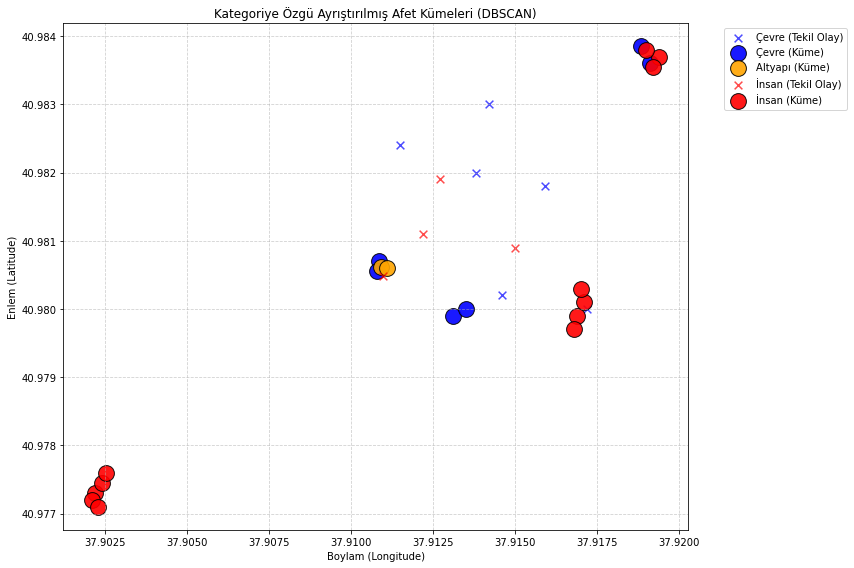

Kümeleme Tamamlandı!
Toplam nihai küme sayısı: 7
Toplam tekil olay sayısı: 10


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. JSON Verisini Okuma
with open('oasis_db_output.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. Makro Kategori Belirleme (Sadece Altyapı ve Çevre için temel sözlük)
macro_mapping = {
    'road collapse': 'altyapi',
    'road_disruption': 'altyapi',
    'infrastructure failure': 'altyapi',
    'elektrik kesintisi': 'altyapi',
    'elektrik kazası': 'altyapi',
    'flood': 'cevre',
    'heyelan': 'cevre',
    'landslide': 'cevre',
    'fire': 'cevre'
}

parsed_data = []
for r in data['processed_reports']:
    lon, lat = r['gps_location']['coordinates']
    # Eğer orijinal afet tipine göre kümeleme yapmak isterseniz macro_category 
    # yerine raw_cat kullanabilirsiniz. Şimdilik makro kategoriyi baz alıyoruz.
    raw_cat = r['disaster_type'].lower().strip()
    
    # --- İNSAN KATEGORİSİ KONTROLÜ (ÖNCELİKLİ) ---
    indicators = r.get('indicators_json', {})
    user_status = r.get('user_status', '')
    
    is_human_risk = (
        indicators.get('people_trapped', False) or 
        indicators.get('people_injured', False) or 
        indicators.get('life_threat', False) or
        user_status == 'entrapment-life-threatening-risk'
    )
    
    if is_human_risk:
        macro_cat = 'insan'
    else:
        macro_cat = macro_mapping.get(raw_cat, 'diger')
        
    parsed_data.append({
        'id': r['id'], 
        'lat': lat, 
        'lon': lon, 
        'macro_category': macro_cat,
        'raw_category': raw_cat # İstenirse diye ham veriyi de tutalım
    })

df = pd.DataFrame(parsed_data)

# 3. ve 4. ADIM: Hem Makro Kategoriye Hem Konuma Göre Bağımsız DBSCAN
# Her kategori için DBSCAN'i ayrı ayrı çalıştırıyoruz.
df['final_cluster'] = -1
global_cluster_id = 0

# Burada macro_category yerine 'raw_category' yazarsanız doğrudan "flood", "fire" gibi
# alt afet tiplerine göre spesifik kümeleme yapar.
for cat_name, group_df in df.groupby('macro_category'):
    
    # Küme oluşturmak için en az min_samples (2) kadar veri olmalı
    if len(group_df) >= 2:
        # Sadece bu kategoriye ait olan veriler üzerinde konumsal tarama yapıyoruz
        dbscan = DBSCAN(eps=0.0005, min_samples=2)
        local_clusters = dbscan.fit_predict(group_df[['lat', 'lon']])
        
        # Local cluster ID'leri (0, 1, 2...) global (benzersiz) cluster ID'lere çevir
        unique_local_clusters = set(local_clusters) - {-1}
        
        # Yerel ID'den Global ID'ye haritalama sözlüğü
        cluster_mapping = {}
        for local_id in unique_local_clusters:
            cluster_mapping[local_id] = global_cluster_id
            global_cluster_id += 1
            
        # Orijinal DataFrame'e atama yap
        for idx, loc_id in zip(group_df.index, local_clusters):
            if loc_id != -1:
                df.at[idx, 'final_cluster'] = cluster_mapping[loc_id]


# 5. Görselleştirme
plt.figure(figsize=(12, 8))

cat_style = {
    'insan':   {'color': 'red',    'label': 'İnsan'},
    'altyapi': {'color': 'orange', 'label': 'Altyapı'},
    'cevre':   {'color': 'blue',   'label': 'Çevre'},
    'diger':   {'color': 'gray',   'label': 'Diğer'}
}

for cat in df['macro_category'].unique():
    cat_df = df[df['macro_category'] == cat]
    color = cat_style[cat]['color']
    label = cat_style[cat]['label']
    
    # Tekil Olayları çiz
    tekil_df = cat_df[cat_df['final_cluster'] == -1]
    if not tekil_df.empty:
        plt.scatter(tekil_df['lon'], tekil_df['lat'], 
                    color=color, marker='x', s=60, alpha=0.7, 
                    label=f"{label} (Tekil Olay)")
    
    # Kümeleri çiz
    kume_df = cat_df[cat_df['final_cluster'] != -1]
    if not kume_df.empty:
        plt.scatter(kume_df['lon'], kume_df['lat'], 
                    color=color, marker='o', s=250, edgecolors='black', alpha=0.9, 
                    label=f"{label} (Küme)")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Kategoriye Özgü Ayrıştırılmış Afet Kümeleri (DBSCAN)')
plt.xlabel('Boylam (Longitude)')
plt.ylabel('Enlem (Latitude)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Özet Çıktı
print("Kümeleme Tamamlandı!")
print(f"Toplam nihai küme sayısı: {global_cluster_id}")
print(f"Toplam tekil olay sayısı: {len(df[df['final_cluster'] == -1])}")